In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
boston_df = pd.read_csv(url)

print("Dataset loaded successfully.")
boston_df.head()


Dataset loaded successfully.


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


--- Column Data Types ---
crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
b          float64
lstat      float64
medv       float64
dtype: object
Missing Values Check
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64
Duplicate Rows Check
Number of duplicate rows: 0


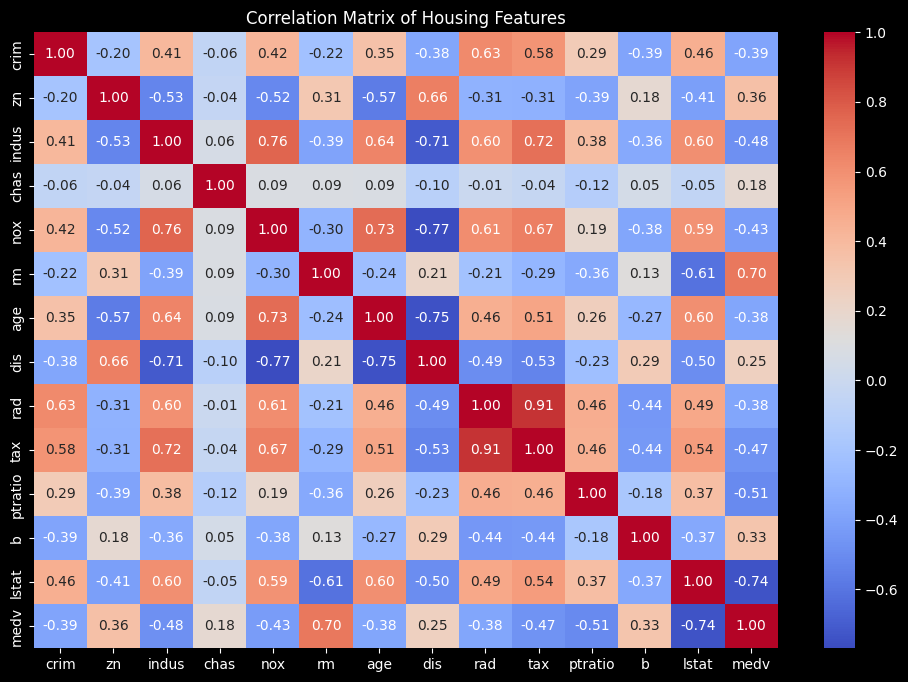

In [5]:
print("--- Column Data Types ---")
print(boston_df.dtypes)

print("Missing Values Check")
print(boston_df.isnull().sum())

print("Duplicate Rows Check")
print(f"Number of duplicate rows: {boston_df.duplicated().sum()}")


plt.figure(figsize=(12, 8))
sns.heatmap(boston_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of Housing Features")
plt.show()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


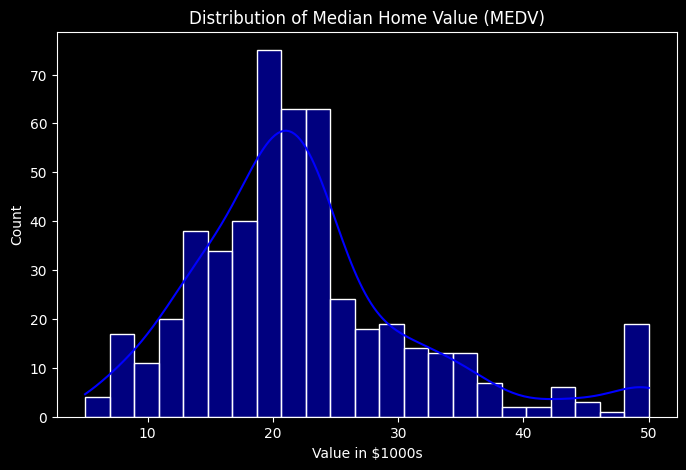

C:\Users\imato\AppData\Local\Temp\ipykernel_20724\972710585.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='chas', data=boston_df, palette='Set1')


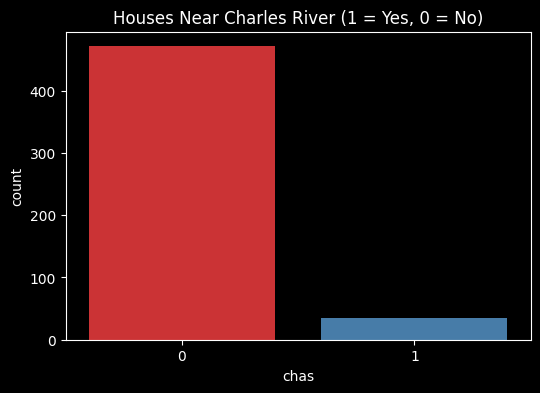

In [6]:
display(boston_df.describe())

plt.figure(figsize=(8, 5))
sns.histplot(boston_df['medv'], kde=True, color='blue')
plt.title("Distribution of Median Home Value (MEDV)")
plt.xlabel("Value in $1000s")
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(x='chas', data=boston_df, palette='Set1')
plt.title("Houses Near Charles River (1 = Yes, 0 = No)")
plt.show()

C:\Users\imato\AppData\Local\Temp\ipykernel_20724\4012708432.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='age_group', y='medv', data=boston_df, palette='Set2')


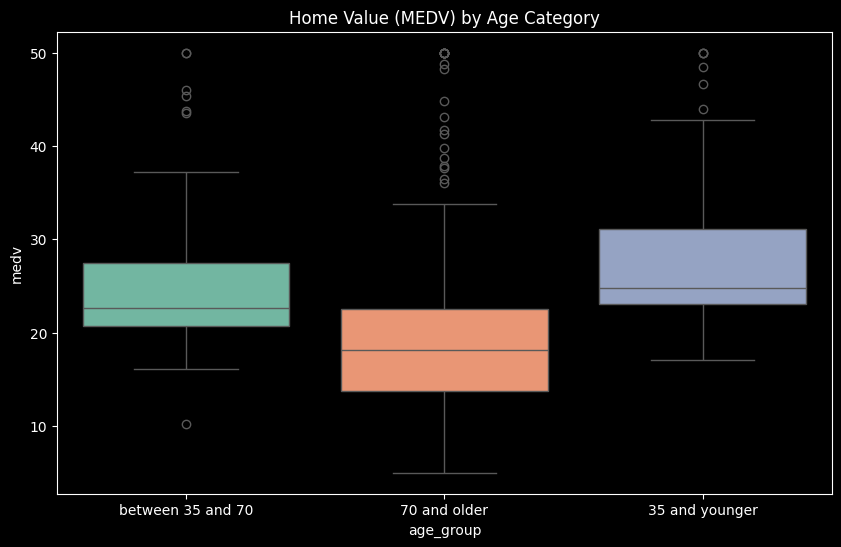

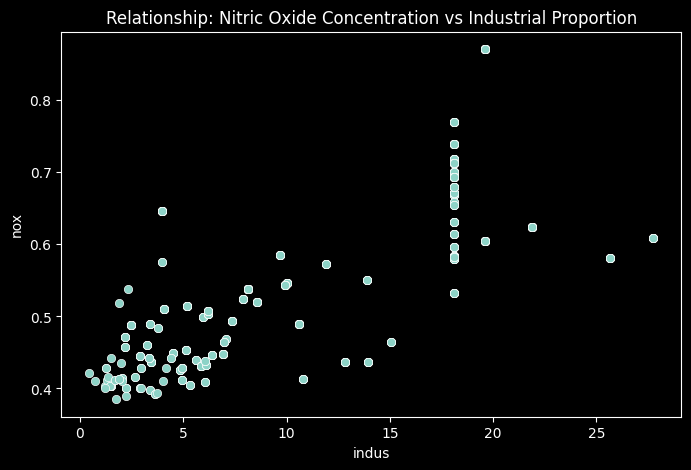

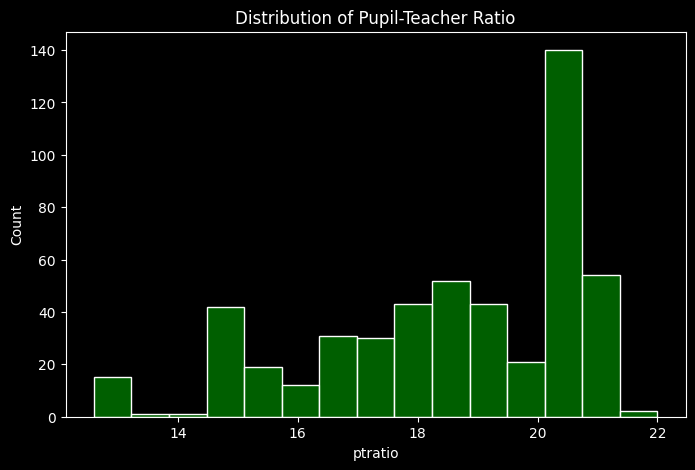

In [7]:

boston_df.loc[(boston_df['age'] <= 35), 'age_group'] = '35 and younger'
boston_df.loc[(boston_df['age'] > 35) & (boston_df['age'] < 70), 'age_group'] = 'between 35 and 70'
boston_df.loc[(boston_df['age'] >= 70), 'age_group'] = '70 and older'

plt.figure(figsize=(10, 6))
sns.boxplot(x='age_group', y='medv', data=boston_df, palette='Set2')
plt.title("Home Value (MEDV) by Age Category")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x='indus', y='nox', data=boston_df)
plt.title("Relationship: Nitric Oxide Concentration vs Industrial Proportion")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(boston_df['ptratio'], bins=15, color='green')
plt.title("Distribution of Pupil-Teacher Ratio")
plt.show()

In [8]:
river = boston_df[boston_df['chas'] == 1]['medv']
no_river = boston_df[boston_df['chas'] == 0]['medv']
l_stat, p_levene = stats.levene(river, no_river)
print(f"Levene's Test p-value: {p_levene:.4f}")

t_stat, p_t = stats.ttest_ind(river, no_river)
print(f"T-Test p-value: {p_t:.4f}")

anova_model = ols('medv ~ age_group', data=boston_df).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
print("\n--- ANOVA Table for Age Groups ---")
print(anova_table)

Levene's Test p-value: 0.0326
T-Test p-value: 0.0001

--- ANOVA Table for Age Groups ---
                 sum_sq     df         F        PR(>F)
age_group   5401.731883    2.0  36.40765  1.710501e-15
Residual   37314.563532  503.0       NaN           NaN


In [9]:
corr, p_corr = stats.pearsonr(boston_df['nox'], boston_df['indus'])
print(f"Pearson Correlation (NOX vs INDUS): r = {corr:.4f}, p-value = {p_corr:.4e}")

X = boston_df['dis']
y = boston_df['medv']
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print("\n--- Linear Regression Summary: Impact of DIS on MEDV ---")
print(model.summary())

Pearson Correlation (NOX vs INDUS): r = 0.7637, p-value = 7.9134e-98

--- Linear Regression Summary: Impact of DIS on MEDV ---
                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.21e-08
Time:                        20:58:58   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----